## Nile Red spectral forward model — step-by-step flow diagram

Companion figure to `FigureSI_NileRed_ForwardModel.ipynb` (the quantitative
bias/precision analysis notebook): this notebook produces a step-by-step,
worked-example illustration of how the Nile Red spectral forward model turns a
true emission wavelength into a fitted wavelength estimate, in the same style
as `FigureSI_SimulationFlowdiagram.ipynb`.

The pipeline has two output paths, both ending in the same wavelength-inversion
fit (`NileRedFunctions.fit_nile_red_wavelength`, a chi-squared/inverse-error
weighted least-squares fit):

1. **Per-localisation (unbinned)** — every individual localisation's own
   photon-limited colour+PSF fit is inverted to a wavelength estimate directly.
2. **Pixellated (binned)** — real analysis (`NileRedFunctions.
   fit_wavelengths_pixelated`) spatially groups multiple localisations that
   land in the same render pixel, combines their already-fitted `A_R`/`A_G`/
   `A_B`/`s_x`/`s_y` via an inverse-error-weighted average
   (`_weighted_average_with_error`) and RGB-renormalises with error
   propagation (`_normalize_rgb_with_errors`), then fits **one** wavelength per
   pixel using the same inversion function. Panel E and the flow diagram below
   highlight this grouping step specifically.

Panels A-D use real `NileRedFunctions`/`SpectralFunctions` calls with a
lightweight, direct Poisson-noise Monte Carlo (no full image simulation --
same approach as `FigureSI_SimulationFlowdiagram.ipynb`'s Panel E) to keep this
notebook fast and focused on illustrating the concepts; the quantitative
bias/precision statistics live in `FigureSI_NileRed_ForwardModel.ipynb`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path

from pyS3M import NileRedFunctions, SpectralFunctions, PlottingBase

NR_F = NileRedFunctions.NileRed_Functions()
S_F = SpectralFunctions.Spectral_Funcs()
plotter = PlottingBase.PublicationPlotter(dark_background=False)

FIGURE_DIR = Path('/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model_FlowDiagram/')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# ── Shared example data ──────────────────────────────────────────────────────
# Same filter set as FigureSI_NileRed_ForwardModel.ipynb.
nilered_filter = "semrock-ff01-650-200"
dichroic_515_mirror = "semrock-di03-r514-t1-25x36"
longpass_filter_515 = "semrock-ff01-515-lp"
filters = [nilered_filter, dichroic_515_mirror, longpass_filter_515]

wavelength_array, pixel_QYs, filter_spectra = NR_F.setup_optical_system(filters)
NA = 1.49
pixel_size_nm = 69.0

print(f'wavelength grid: {wavelength_array.min():.0f}-{wavelength_array.max():.0f} nm, '
      f'{len(wavelength_array)} points')

wavelength grid: 400-999 nm, 600 points


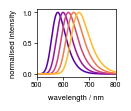

In [4]:
# ── Panel A -- Nile Red emission spectra at a few true (peak) wavelengths ──
# generate_nile_red_spectrum's own `wavelength_center` argument is an energy-space
# location parameter, not the rendered spectrum's peak (the two differ by tens of
# nm -- see wavelength_center_for_peak's docstring) -- convert first, so the peak
# wavelengths labelled here really are where each spectrum peaks.
peak_wavelengths_example = np.array([580.0, 600.0, 620.0, 640.0, 660.0])
panelA_colours = plt.cm.plasma(np.linspace(0.15, 0.85, len(peak_wavelengths_example)))

fig, ax = plotter.one_column_plot(height=1, width=1.2)
for pk, c in zip(peak_wavelengths_example, panelA_colours):
    wc = NR_F.wavelength_center_for_peak(pk, wavelength_array)
    spectrum = NR_F.generate_nile_red_spectrum(wc, wavelength_array, normalize=True)
    ax.plot(wavelength_array, spectrum / spectrum.max(), color=c, lw=1.1, label=f'{pk:.0f} nm')

ax.set_xlim([500, 800])
ax.set_xlabel('wavelength / nm', fontsize=5.5)
ax.set_ylabel('normalised intensity', fontsize=5.5)
ax.tick_params(labelsize=5)

plt.savefig(FIGURE_DIR / 'panelA_nile_red_spectra.svg', format='svg', dpi=600)
plt.show()

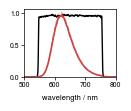

In [5]:
# ── Panel B -- optical filters truncate the emission spectrum ──────────────
filter_total = np.prod(filter_spectra, axis=0) if filter_spectra.ndim > 1 else filter_spectra

wc_example = NR_F.wavelength_center_for_peak(620.0, wavelength_array)
spectrum_example = NR_F.generate_nile_red_spectrum(wc_example, wavelength_array, normalize=True)
spectrum_example_norm = spectrum_example / spectrum_example.max()
spectrum_filtered_example = NR_F.apply_optical_filters(spectrum_example, filter_spectra)
spectrum_filtered_norm = spectrum_filtered_example / spectrum_example.max()

fig, ax = plotter.one_column_plot(height=1, width=1.2)
ax.plot(wavelength_array, filter_total, color='k', lw=1.0, label='filters')
ax.plot(wavelength_array, spectrum_example_norm, color='#cc4444', lw=1.0, alpha=0.45, ls='--',
        label='NR spectrum (620 nm)')
ax.plot(wavelength_array, spectrum_filtered_norm, color='#cc4444', lw=1.2, label='filtered')
ax.set_xlim([500, 800])
ax.set_ylim([0, 1.05])
ax.set_xlabel('wavelength / nm', fontsize=5.5)
ax.tick_params(labelsize=5)

plt.savefig(FIGURE_DIR / 'panelB_filter_truncation.svg', format='svg', dpi=600)
plt.show()

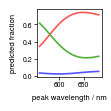

In [6]:
# ── Panel C -- forward model: predicted R:G:B fractions and PSF width vs. true
# wavelength (× Bayer pixel QE, calculate_rgb_from_spectrum /
# calculate_psf_width_from_spectrum) -- this is the deterministic prediction that
# fit_nile_red_wavelength's least-squares inversion fits observed data against.
peak_wavelengths_fine = np.linspace(560, 680, 25)
R_pred, G_pred, B_pred, sigma_pred = [], [], [], []
for pk in peak_wavelengths_fine:
    wc = NR_F.wavelength_center_for_peak(pk, wavelength_array)
    spectrum = NR_F.generate_nile_red_spectrum(wc, wavelength_array, normalize=True)
    spectrum_f = NR_F.apply_optical_filters(spectrum, filter_spectra)
    rgb = NR_F.calculate_rgb_from_spectrum(spectrum_f, wavelength_array, pixel_QYs)
    sigma = NR_F.calculate_psf_width_from_spectrum(spectrum_f, wavelength_array, NA)
    R_pred.append(rgb[0]); G_pred.append(rgb[1]); B_pred.append(rgb[2]); sigma_pred.append(sigma)

fig, axs = plotter.two_column_plot(ncols=1, width=1, height=1.0)
axs.plot(peak_wavelengths_fine, R_pred, color='#ff5555', lw=1.2, label='R')
axs.plot(peak_wavelengths_fine, G_pred, color='#53b03b', lw=1.2, label='G')
axs.plot(peak_wavelengths_fine, B_pred, color='#5555ff', lw=1.2, label='B')
axs.set_xlabel('peak wavelength / nm', fontsize=5.5)
axs.set_ylabel('predicted fraction', fontsize=5.5)
axs.tick_params(labelsize=5)

plt.savefig(FIGURE_DIR / 'panelC_forward_model.svg', format='svg', dpi=600)
plt.show()

true wavelength (centre of mass): 634.1 nm
individual (unbinned) fits: mean=632.4 nm, std=6.2 nm


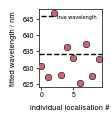

In [7]:
# ── Panel D -- photon-limited single-molecule fits, unbinned ───────────────
# Direct Poisson-noise Monte Carlo on the deterministic forward-model prediction
# (no full image simulation -- illustrative, not the quantitative bias/precision
# analysis, which lives in FigureSI_NileRed_ForwardModel.ipynb), feeding the SAME
# real wavelength-inversion fit (fit_nile_red_wavelength) used by production code.
rng = np.random.default_rng(7)
WL_TRUE_EXAMPLE = 620.0
N_PHOTONS_EXAMPLE = 500.0
BACKGROUND_EXAMPLE = 45.0
N_EXAMPLE_LOCS = 10

wc_true = NR_F.wavelength_center_for_peak(WL_TRUE_EXAMPLE, wavelength_array)
wl_true_com = NR_F.spectral_centre_of_mass(wc_true, wavelength_array)
spectrum_true = NR_F.generate_nile_red_spectrum(wc_true, wavelength_array, normalize=True)
spectrum_true_f = NR_F.apply_optical_filters(spectrum_true, filter_spectra)
rgb_true = NR_F.calculate_rgb_from_spectrum(spectrum_true_f, wavelength_array, pixel_QYs)
sigma_true = NR_F.calculate_psf_width_from_spectrum(spectrum_true_f, wavelength_array, NA)


def simulate_localisation(n_photons, rng):
    """One photon-limited localisation: Poisson-noisy R/G/B (+ background) and a
    PSF width with a small fractional error, then invert to a wavelength estimate
    via the real fit_nile_red_wavelength."""
    bg_per_channel = BACKGROUND_EXAMPLE / 3.0
    signal_counts = rng.poisson(rgb_true * n_photons)
    bg_counts = rng.poisson(np.full(3, bg_per_channel))
    rgb_obs = (signal_counts + bg_counts).astype(float)
    rgb_err = np.sqrt(rgb_obs)
    rgb_err[rgb_err == 0] = 1.0

    sigma_err_frac = 0.05
    sx_obs = sigma_true * (1 + rng.normal(0, sigma_err_frac))
    sy_obs = sigma_true * (1 + rng.normal(0, sigma_err_frac))
    sx_err = sigma_true * sigma_err_frac
    sy_err = sigma_true * sigma_err_frac

    wl, _ = NR_F.fit_nile_red_wavelength(
        observed_rgb=rgb_obs, observed_sigma_x=sx_obs, observed_sigma_y=sy_obs,
        rgb_errors=rgb_err, sigma_x_error=sx_err, sigma_y_error=sy_err,
        filter_spectra=filter_spectra, wavelength_array=wavelength_array,
        pixel_QYs=pixel_QYs, NA=NA, total_photons=n_photons,
        background_photons=BACKGROUND_EXAMPLE,
    )
    return dict(
        A_R=rgb_obs[0] / rgb_obs.sum(), A_G=rgb_obs[1] / rgb_obs.sum(), A_B=rgb_obs[2] / rgb_obs.sum(),
        A_R_err=rgb_err[0] / rgb_obs.sum(), A_G_err=rgb_err[1] / rgb_obs.sum(), A_B_err=rgb_err[2] / rgb_obs.sum(),
        s_x=sx_obs, s_y=sy_obs, s_x_err=sx_err, s_y_err=sy_err,
        photons=n_photons, background_photons=BACKGROUND_EXAMPLE, wl_fit=wl,
    )


individual_locs = [simulate_localisation(N_PHOTONS_EXAMPLE, rng) for _ in range(N_EXAMPLE_LOCS)]
individual_wls = np.array([r['wl_fit'] for r in individual_locs])

fig, ax = plotter.one_column_plot(height=1.1, width=1)
ax.scatter(np.arange(N_EXAMPLE_LOCS), individual_wls, s=22, color='#cc6677', edgecolor='k', linewidth=0.4, zorder=3)
ax.axhline(wl_true_com, color='k', ls='--', lw=1.0, zorder=1, label='true wavelength')
ax.set_xlabel('individual localisation #', fontsize=5.5)
ax.set_ylabel('fitted wavelength / nm', fontsize=5.5)
ax.tick_params(labelsize=5)
ax.legend(fontsize=4, frameon=False)

print(f'true wavelength (centre of mass): {wl_true_com:.1f} nm')
print(f'individual (unbinned) fits: mean={individual_wls.mean():.1f} nm, std={individual_wls.std():.1f} nm')

plt.savefig(FIGURE_DIR / 'panelD_individual_fits.svg', format='svg', dpi=600)
plt.show()

In [10]:
ax.get_ylim()

(624.0215797345475, 647.9201980009158)

group of 12 localisations, total photons=10300
individual (unbinned) fits in this group: mean=628.1 nm, std=9.1 nm
combined (pixellated) fit: 634.4 nm (true=634.1 nm)


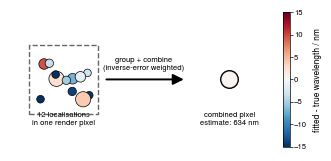

In [12]:
# ── Panel E -- PIXELLATION: grouping localisations that land in the same render
# pixel, exactly as real analysis does it (NileRedFunctions.fit_wavelengths_pixelated):
# an inverse-error-weighted average of each localisation's own already-fitted
# A_R/A_G/A_B/s_x/s_y, RGB-renormalised with error propagation, then ONE
# wavelength fit for the whole group -- not a re-fit on combined raw images.
rng2 = np.random.default_rng(11)
N_GROUP = 12
photon_choices_example = np.array([100.0, 300.0, 1000.0, 3000.0])
group_photons = rng2.choice(photon_choices_example, size=N_GROUP)
group_xy = rng2.uniform(-0.5, 0.5, size=(N_GROUP, 2))  # illustrative positions within one render pixel

group_locs = [simulate_localisation(n_ph, rng2) for n_ph in group_photons]
df_group = pd.DataFrame(group_locs)
group_wls = df_group['wl_fit'].to_numpy()


def combine_and_fit_group(df_group):
    """Combine a group of localisations into one pixel-level wavelength estimate,
    exactly as fit_wavelengths_pixelated does for a real pixel: inverse-error-
    weighted average of each localisation's own already-fitted A_R/A_G/A_B/s_x/s_y,
    RGB-renormalised with error propagation, then one shared wavelength-inversion
    fit. Returns (wl_pixel, total_photons, total_background_photons)."""
    avg_R, avg_R_err = NR_F._weighted_average_with_error(df_group['A_R'].to_numpy(), df_group['A_R_err'].to_numpy())
    avg_G, avg_G_err = NR_F._weighted_average_with_error(df_group['A_G'].to_numpy(), df_group['A_G_err'].to_numpy())
    avg_B, avg_B_err = NR_F._weighted_average_with_error(df_group['A_B'].to_numpy(), df_group['A_B_err'].to_numpy())
    avg_sx, avg_sx_err = NR_F._weighted_average_with_error(df_group['s_x'].to_numpy(), df_group['s_x_err'].to_numpy())
    avg_sy, avg_sy_err = NR_F._weighted_average_with_error(df_group['s_y'].to_numpy(), df_group['s_y_err'].to_numpy())

    rgb_avg = np.array([avg_R, avg_G, avg_B])
    rgb_avg_err = np.array([avg_R_err, avg_G_err, avg_B_err])
    rgb_norm, rgb_norm_err = NR_F._normalize_rgb_with_errors(rgb_avg, rgb_avg_err)

    total_photons = float(df_group['photons'].sum())
    total_bg = float(df_group['background_photons'].sum())

    wl_pixel, _ = NR_F.fit_nile_red_wavelength(
        observed_rgb=rgb_norm, observed_sigma_x=avg_sx, observed_sigma_y=avg_sy,
        rgb_errors=rgb_norm_err, sigma_x_error=avg_sx_err, sigma_y_error=avg_sy_err,
        filter_spectra=filter_spectra, wavelength_array=wavelength_array,
        pixel_QYs=pixel_QYs, NA=NA, total_photons=total_photons,
        background_photons=total_bg,
    )
    return wl_pixel, total_photons, total_bg


wl_pixel, group_total_photons, group_total_bg = combine_and_fit_group(df_group)

print(f'group of {N_GROUP} localisations, total photons={group_total_photons:.0f}')
print(f'individual (unbinned) fits in this group: mean={group_wls.mean():.1f} nm, std={group_wls.std():.1f} nm')
print(f'combined (pixellated) fit: {wl_pixel:.1f} nm (true={wl_true_com:.1f} nm)')

fig, ax = plotter.one_column_plot(height=2.0, width=3.2)
bias_norm = plt.Normalize(vmin=-15, vmax=15)
sizes = 30 + 90 * (group_photons - group_photons.min()) / (group_photons.max() - group_photons.min() + 1e-9)

ax.add_patch(plt.Rectangle((-0.65, -0.65), 1.3, 1.3, fill=False, edgecolor='0.4', lw=1.0, ls='--'))
sc = ax.scatter(group_xy[:, 0], group_xy[:, 1], s=sizes, c=group_wls - wl_true_com, cmap='RdBu_r',
                 norm=bias_norm, edgecolor='k', linewidth=0.5, zorder=3)
ax.annotate('', xy=(2.3, 0.0), xytext=(0.75, 0.0),
            arrowprops=dict(arrowstyle='-|>', color='k', lw=1.4, mutation_scale=16))
ax.text(1.5, 0.18, 'group + combine\n(inverse-error weighted)', ha='center', fontsize=5.5)
ax.scatter([3.1], [0.0], s=160, c=[wl_pixel - wl_true_com], cmap='RdBu_r', norm=bias_norm,
           edgecolor='k', linewidth=1.0, zorder=3, marker='o')
ax.text(3.1, -0.85, f'combined pixel\nestimate: {wl_pixel:.0f} nm', ha='center', fontsize=5.5)
ax.text(0.0, -0.85, f'{N_GROUP} localisations\nin one render pixel', ha='center', fontsize=5.5)

cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('fitted - true wavelength / nm', fontsize=6)
cbar.ax.tick_params(labelsize=5.5)

ax.set_xlim([-1.0, 4.0])
ax.set_ylim([-1.3, 1.3])
ax.set_aspect('equal')
ax.axis('off')

plt.savefig(FIGURE_DIR / 'panelE_pixellation.svg', format='svg', dpi=600)
plt.show()

pixellated (grouped, N=12 localisations/pixel) fits: mean=634.6 nm, std=1.2 nm
(cf. individual/unbinned fits: mean=632.4 nm, std=6.2 nm)


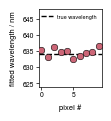

In [13]:
# ── Panel F -- like Panel D, but per PIXEL: each point is a pixellated (grouped)
# wavelength estimate (N_GROUP localisations pooled via combine_and_fit_group, the
# same real per-pixel combination as Panel E) rather than a single localisation's
# own fit -- repeated over many independent pixels. Scatter should be far lower
# than Panel D's, since each pixel pools ~N_GROUP times the photons.
rng3 = np.random.default_rng(13)
N_EXAMPLE_PIXELS = 10

pixel_wls = np.full(N_EXAMPLE_PIXELS, np.nan)
for p in range(N_EXAMPLE_PIXELS):
    pixel_photons = rng3.choice(photon_choices_example, size=N_GROUP)
    pixel_locs = [simulate_localisation(n_ph, rng3) for n_ph in pixel_photons]
    df_pixel = pd.DataFrame(pixel_locs)
    wl_pixel_p, _, _ = combine_and_fit_group(df_pixel)
    pixel_wls[p] = wl_pixel_p

fig, ax = plotter.one_column_plot(height=1.1, width=1)
ax.scatter(np.arange(N_EXAMPLE_PIXELS), pixel_wls, s=22, color='#cc6677', edgecolor='k', linewidth=0.4, zorder=3)
ax.axhline(wl_true_com, color='k', ls='--', lw=1.0, zorder=1, label='true wavelength')
ax.set_xlabel('pixel #', fontsize=5.5)
ax.set_ylabel('fitted wavelength / nm', fontsize=5.5)
ax.tick_params(labelsize=5)
ax.legend(fontsize=4, frameon=False)
ax.set_ylim([624.0215797345475, 647.9201980009158])

print(f'pixellated (grouped, N={N_GROUP} localisations/pixel) fits: '
      f'mean={np.nanmean(pixel_wls):.1f} nm, std={np.nanstd(pixel_wls):.1f} nm')
print(f'(cf. individual/unbinned fits: mean={individual_wls.mean():.1f} nm, std={individual_wls.std():.1f} nm)')

plt.savefig(FIGURE_DIR / 'panelF_pixel_fits.svg', format='svg', dpi=600)
plt.show()

### Flow diagram

Schematic summary of the pipeline demonstrated in Panels A-E above: the
spectral forward-model chain (true wavelength -> spectrum -> filters -> Bayer
QE, Panels A-C) is shared, then a photon-limited single-molecule fit (Panel D)
feeds two paths that both end in the same wavelength-inversion fit
(`fit_nile_red_wavelength`) -- the unbinned per-localisation path (left), and
the **pixellation** path (right, highlighted), which groups multiple
localisations landing in the same render pixel before combining and fitting
once per pixel (Panel E).

/tmp/ipykernel_3415004/960081891.py:108: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


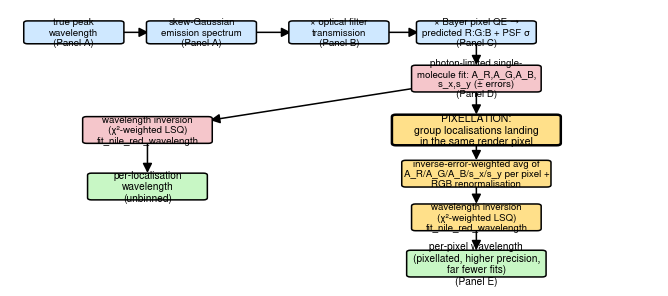

In [9]:
# ── Flow diagram: box/arrow schematic of the full pipeline ─────────────────
# Arrows are clipped to each box's actual rectangle boundary (plus a small
# margin) rather than shrunk by a fixed point offset from box centres -- a
# fixed-point shrink left the arrowhead sitting under the box's opaque
# facecolor (higher zorder), making it invisible. Same helper functions as
# FigureSI_SimulationFlowdiagram.ipynb's flow diagram cell.
fig, ax = plotter.two_column_plot()
ax.set_xlim(0, 13.2)
ax.set_ylim(-2.2, 8.3)
ax.axis('off')

SPEC_C = '#cfe8ff'    # shared spectral forward-model stages
LOC_C = '#f5c6cb'     # single-localisation / photon-limited stages
PIX_C = '#ffe08a'     # pixellation-specific stages -- the highlighted step
OUTPUT_C = '#c8f7c5'  # final outputs

node_boxes = {}


def add_node(name, x, y, w, h, text, colour, fontsize=7.0, linewidth=1.1):
    box = FancyBboxPatch(
        (x - w / 2, y - h / 2), w, h,
        boxstyle='round,pad=0.02,rounding_size=0.08',
        linewidth=linewidth, edgecolor='black', facecolor=colour, zorder=2,
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, zorder=3)
    node_boxes[name] = (x, y, w, h)


def edge_point(cx, cy, w, h, tx, ty, margin=0.08):
    """Point on the box (cx,cy,w,h) boundary along the direction to (tx,ty),
    pulled back by `margin` data units so the arrowhead sits in open space."""
    dx, dy = tx - cx, ty - cy
    dist = np.hypot(dx, dy)
    if dist == 0:
        return cx, cy
    ux, uy = dx / dist, dy / dist
    halfw, halfh = w / 2, h / 2
    ts = []
    if ux != 0:
        ts.append(halfw / abs(ux))
    if uy != 0:
        ts.append(halfh / abs(uy))
    t_edge = min(ts)
    ex, ey = cx + ux * t_edge, cy + uy * t_edge
    return ex - ux * margin, ey - uy * margin


def add_arrow(src, dst, **kwargs):
    x1, y1, w1, h1 = node_boxes[src]
    x2, y2, w2, h2 = node_boxes[dst]
    start = edge_point(x1, y1, w1, h1, x2, y2)
    end = edge_point(x2, y2, w2, h2, x1, y1)
    style = dict(arrowstyle='-|>', mutation_scale=14, linewidth=1.1, color='black', zorder=1)
    style.update(kwargs)
    arrow = FancyArrowPatch(start, end, **style)
    ax.add_patch(arrow)


# Row 1 (shared spectral forward-model chain, Panels A-C)
add_node('true_wl', 1.3, 7.4, 2.0, 0.85, 'true peak\nwavelength\n(Panel A)', SPEC_C)
add_node('spectrum', 3.9, 7.4, 2.2, 0.85, 'skew-Gaussian\nemission spectrum\n(Panel A)', SPEC_C)
add_node('filter', 6.7, 7.4, 2.0, 0.85, '× optical filter\ntransmission\n(Panel B)', SPEC_C)
add_node('forward', 9.5, 7.4, 2.4, 0.85, '× Bayer pixel QE →\npredicted R:G:B + PSF σ\n(Panel C)', SPEC_C)

# Row 2: one photon-limited single-molecule fit (Panel D) -- this is the shared
# entry point for BOTH downstream paths.
add_node('singleloc', 9.5, 5.6, 2.6, 1.0,
         'photon-limited single-\nmolecule fit: A_R,A_G,A_B,\ns_x,s_y (± errors)\n(Panel D)', LOC_C)

# Individual (unbinned) path -- left.
add_node('fit_individual', 2.8, 3.6, 2.6, 1.0,
         'wavelength inversion\n(χ²-weighted LSQ)\nfit_nile_red_wavelength', LOC_C)
add_node('out_individual', 2.8, 1.4, 2.4, 1.0,
         'per-localisation\nwavelength\n(unbinned)', OUTPUT_C, fontsize=7.3)

# Pixellation path -- right, highlighted (bigger box, thicker border).
add_node('pixellate', 9.5, 3.6, 3.4, 1.15,
         'PIXELLATION:\ngroup localisations landing\nin the same render pixel', PIX_C,
         fontsize=7.6, linewidth=1.8)
add_node('combine', 9.5, 1.9, 3.0, 1.0,
         'inverse-error-weighted avg of\nA_R/A_G/A_B/s_x/s_y per pixel +\nRGB renormalisation', PIX_C)
add_node('fit_pixel', 9.5, 0.2, 2.6, 1.0,
         'wavelength inversion\n(χ²-weighted LSQ)\nfit_nile_red_wavelength', PIX_C)
add_node('out_pixel', 9.5, -1.6, 2.8, 1.0,
         'per-pixel wavelength\n(pixellated, higher precision,\nfar fewer fits)\n(Panel E)',
         OUTPUT_C, fontsize=7.3)

# Arrows: shared chain
add_arrow('true_wl', 'spectrum')
add_arrow('spectrum', 'filter')
add_arrow('filter', 'forward')
add_arrow('forward', 'singleloc')

# Individual (unbinned) path
add_arrow('singleloc', 'fit_individual')
add_arrow('fit_individual', 'out_individual')

# Pixellation path: singleloc is itself one of the group, plus several other
# localisations converge into the SAME pixellation box -- this convergence of
# several arrows is the visual highlight of the grouping step.
add_arrow('singleloc', 'pixellate')
add_arrow('pixellate', 'combine')
add_arrow('combine', 'fit_pixel')
add_arrow('fit_pixel', 'out_pixel')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'flow_diagram.svg', format='svg', dpi=600)
plt.show()